In [52]:
import pandas as pd
from scipy.stats import ttest_ind, t
import pandas as pd
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
from math import sqrt, ceil, floor
import numpy as np

## O app usado para o teste AB tem um pequeno problema na transportação do dado do teste
- Caso o usuário coloque em tela cheia ou mude de direção do dispositivo, ele duplica o dado mudando somente a interação da tela, mas o dado que nos importa permanece o mesmo
- Como o que nos interessa é o tempo, filtramos pelo ID e usamos o tempo

### Coluna que vamos usar:
#### - Tester ID -> Id da sessão do teste
#### - Tempo de tela -> Tempo que o usuário demorou naquela tela

### Função para remover as duplicadas de teste e deixar somente as colunas importantes

In [53]:
def tratar_dados(df: pd.DataFrame) -> pd.DataFrame:
    if "Tester ID" not in df.columns:
        raise ValueError("O DataFrame deve conter uma coluna chamada 'Tester ID'.")

    df_sem_duplicatas = df.drop_duplicates(
        subset=["Tester ID"], keep="first"
    ).reset_index(drop=True)

    df_result = df_sem_duplicatas[["Tester ID", "Total duration (seconds)"]]
    # mudar nome da coluna Total Duration
    df_result = df_result.rename(columns={"Total duration (seconds)": "Tempo de tela"})
    return df_result

### Carregamento do csv de cada tela de cada fluxo

In [54]:
df_acessar_configuracoes_A = pd.read_csv("dados/acessar_configuracoes/A.csv")
df_acessar_configuracoes_B = pd.read_csv("dados/acessar_configuracoes/B.csv")

df_abrir_chatbot_A = pd.read_csv("dados/abrir_chatbot/A.csv")
df_abrir_chatbot_B = pd.read_csv("dados/abrir_chatbot/B.csv")

df_concluir_analise_viagem_A = pd.read_csv("dados/concluir_analise_viagem/A.csv")
df_concluir_analise_viagem_B = pd.read_csv("dados/concluir_analise_viagem/B.csv")

df_filtrar_ranking_A = pd.read_csv("dados/filtrar_ranking_motoristas/A.csv")
df_filtrar_ranking_B = pd.read_csv("dados/filtrar_ranking_motoristas/B.csv")

### Tratando cada dado

In [55]:
df_abrir_chatbot_A = tratar_dados(df_abrir_chatbot_A)
df_abrir_chatbot_B = tratar_dados(df_abrir_chatbot_B)

df_acessar_configuracoes_A = tratar_dados(df_acessar_configuracoes_A)
df_acessar_configuracoes_B = tratar_dados(df_acessar_configuracoes_B)

df_concluir_analise_viagem_A = tratar_dados(df_concluir_analise_viagem_A)
df_concluir_analise_viagem_B = tratar_dados(df_concluir_analise_viagem_B)

df_filtrar_ranking_A = tratar_dados(df_filtrar_ranking_A)
df_filtrar_ranking_B = tratar_dados(df_filtrar_ranking_B)

df_abrir_chatbot_B

,Tester ID,Tempo de tela
0,455165357,28.94
1,301227503,7.92
2,455195293,10.17
3,455339232,1.87
4,455720185,1.90
5,455777544,8.06
6,456493983,18.46
7,456551311,2.91
8,456726697,10.32
9,457222323,174.36


### Somar todo o tempo de tela do usuário somando as quatro telas

In [56]:
df_tempo_tela_total_A = pd.concat(
    # Concatenar todos os fluxos A, fazer a média de tempo por usuário
    [
        df_abrir_chatbot_A,
        df_acessar_configuracoes_A,
        df_concluir_analise_viagem_A,
        df_filtrar_ranking_A,
    ]
)

print("DESCRIBE TELA A")
print(df_tempo_tela_total_A.describe())

df_tempo_tela_total_A = (
    df_tempo_tela_total_A.groupby("Tester ID")["Tempo de tela"].sum().reset_index()
)
df_tempo_tela_total_A

df_tempo_tela_total_B = pd.concat(
    # Concatenar todos os fluxos A, fazer a média de tempo por usuário
    [
        df_abrir_chatbot_B,
        df_acessar_configuracoes_B,
        df_concluir_analise_viagem_B,
        df_filtrar_ranking_B,
    ]
)
print("DESCRIBE TELA B")
print(df_tempo_tela_total_B.describe())
df_tempo_tela_total_B = (
    df_tempo_tela_total_B.groupby("Tester ID")["Tempo de tela"].sum().reset_index()
)

DESCRIBE TELA A
          Tester ID  Tempo de tela
count  6.200000e+01      62.000000
mean   4.425344e+08      19.044355
std    5.266668e+07      15.417740
min    2.436418e+08       1.410000
25%    4.551653e+08       8.152500
50%    4.564940e+08      15.900000
75%    4.570452e+08      24.572500
max    4.578822e+08      84.440000
DESCRIBE TELA B
          Tester ID  Tempo de tela
count  5.100000e+01      51.000000
mean   4.442074e+08      21.576667
std    4.213531e+07      30.347222
min    3.012275e+08       1.870000
25%    4.553392e+08       7.450000
50%    4.564940e+08      12.470000
75%    4.572221e+08      22.310000
max    4.577277e+08     174.360000


### Observando outliers

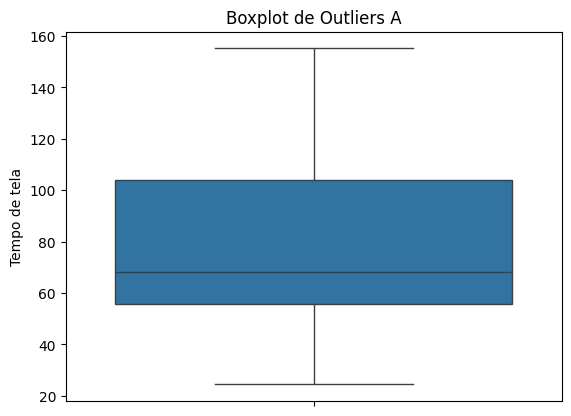

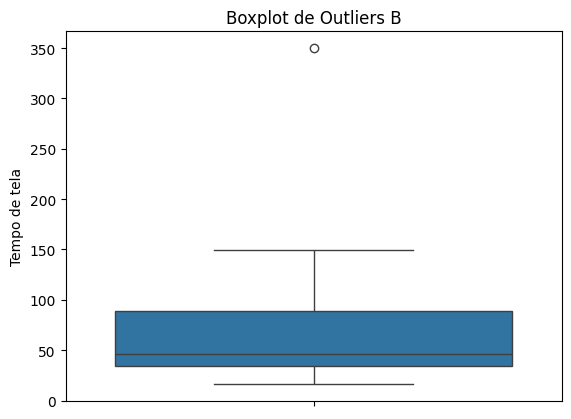

In [57]:
sns.boxplot(data=df_tempo_tela_total_A, y=df_tempo_tela_total_A["Tempo de tela"])
plt.title("Boxplot de Outliers A")
plt.show()


sns.boxplot(data=df_tempo_tela_total_B, y=df_tempo_tela_total_B["Tempo de tela"])
plt.title("Boxplot de Outliers B")
plt.show()

#### Outlier do A

In [58]:
Q1 = df_tempo_tela_total_A["Tempo de tela"].quantile(0.25)
Q3 = df_tempo_tela_total_A["Tempo de tela"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_tempo_tela_total_A[
    (df_tempo_tela_total_A["Tempo de tela"] < limite_inferior)
    | (df_tempo_tela_total_A["Tempo de tela"] > limite_superior)
]
print(outliers)

Empty DataFrame
Columns: [Tester ID, Tempo de tela]
Index: []


#### Outlier do B

In [59]:
Q1 = df_tempo_tela_total_B["Tempo de tela"].quantile(0.25)
Q3 = df_tempo_tela_total_B["Tempo de tela"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_tempo_tela_total_B[
    (df_tempo_tela_total_B["Tempo de tela"] < limite_inferior)
    | (df_tempo_tela_total_B["Tempo de tela"] > limite_superior)
]
print(outliers)

    Tester ID  Tempo de tela
11  457222323         349.94


#### Retirando os outliers

In [60]:
#### Retirando os outliers
## B = 457222323
df_tempo_tela_total_B = df_tempo_tela_total_B[
    df_tempo_tela_total_B["Tester ID"] != 457222323
]

### Separando os tempos de cada teste

In [61]:
tempo_a = df_tempo_tela_total_A["Tempo de tela"]
tempo_b = df_tempo_tela_total_B["Tempo de tela"]

print(tempo_a.describe())
print(tempo_b.describe())
display(tempo_a)
display(tempo_b)

count     16.000000
mean      73.796875
std       35.040691
min       24.420000
25%       55.787500
50%       68.280000
75%      103.982500
max      155.180000
Name: Tempo de tela, dtype: float64
count     13.000000
mean      57.728462
std       41.917954
min       16.180000
25%       34.010000
50%       41.880000
75%       70.810000
max      149.320000
Name: Tempo de tela, dtype: float64


0      24.42
1      73.14
2     104.65
3      39.10
4      31.18
5      28.95
6      76.96
7      69.14
8      65.61
9     108.25
10    103.79
11    155.18
12    104.56
13     67.05
14     67.42
15     61.35
Name: Tempo de tela, dtype: float64

0      50.89
1      70.81
2     125.09
3      17.18
4      34.01
5      57.39
6      94.43
7      16.18
8      17.50
9      39.40
10    149.32
12     41.88
13     36.39
Name: Tempo de tela, dtype: float64

### Test-t studend usando scipy.stats

In [62]:
stat, p = ttest_ind(tempo_a, tempo_b, equal_var=False, alternative="greater")
print(f"t = {stat:.4f}, p = {p:.9f}")
if p < 0.05:  # nível de significância de 5%
    print("Rejeitamos H0: há evidência de que A > B (logo B é mais rápido).")
else:
    print("Não há evidência de que A > B (não podemos afirmar que B é mais rápido).")

t = 1.1038, p = 0.140432256
Não há evidência de que A > B (não podemos afirmar que B é mais rápido).


### Test-t studend usando pingouin

In [63]:
# Realizando o teste t com Pingouin
result = pg.ttest(
    tempo_a, tempo_b, paired=False, alternative="greater", correction=True
)

# Exibindo os resultados
print(result[["T", "p-val", "dof"]])


if result["p-val"][0] < 0.05:  # nível de significância de 5%
    print(
        "Há diferença estatisticamente significativa — o Teste B reduziu o tempo em relação ao A."
    )
else:
    print("Não há diferença estatisticamente significativa entre os grupos.")

               T     p-val        dof
T-test  1.103835  0.140432  23.447793
Não há diferença estatisticamente significativa entre os grupos.


C:\Users\migue\AppData\Local\Temp\ipykernel_21444\2882738292.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if result['p-val'][0] < 0.05: # nível de significância de 5%


### Calculando tudo na mão 

In [64]:
media_a = tempo_a.mean()
media_b = tempo_b.mean()

var_a = tempo_a.var()
var_b = tempo_b.var()

n_a = len(tempo_a)
n_b = len(tempo_b)

t_test = (media_a - media_b) / sqrt((var_a / n_a) + (var_b / n_b))

baixo_df = ((var_a / n_a) ** 2) / (n_a - 1) + ((var_b / n_b) ** 2) / (n_b - 1)

df = ((var_a / n_a + var_b / n_b) ** 2) / baixo_df

print(f"Média A: {media_a}")
print(f"Média B: {media_b}\n")
print(f"Variancia A: {var_a}")
print(f"Variancia B: {var_b}\n")
print(f"T-teste: {t_test}\n")
print(f"Degrees of freedom (Grau de liberdade): {df}")
print(f"Df inteiro para cima: {ceil(df)}")
print(f"Df inteiro para baixo: {floor(df)}")

Média A: 73.796875
Média B: 57.72846153846154

Variancia A: 1227.8500362500001
Variancia B: 1757.114880769231

T-teste: 1.1038349163026882

Degrees of freedom (Grau de liberdade): 23.44779344226001
Df inteiro para cima: 24
Df inteiro para baixo: 23


### Pontuando os valores na tabela T

In [65]:
grau_de_liberdade = 23.44779344226001

y_95 = t.ppf(1 - 0.05, grau_de_liberdade)
y_99 = t.ppf(1 - 0.01, grau_de_liberdade)

print(f"Limite crítico 95% (t_crit): {y_95:.4f}")
print(f"Limite crítico 99% (t_crit): {y_99:.4f}\n")

Limite crítico 95% (t_crit): 1.7125
Limite crítico 99% (t_crit): 2.4963



In [66]:
if t_test > y_95:
    print(
        "Evidências de que o Teste B teve tempo menor que o Teste A com 95% de confiança."
    )
else:
    print(
        "Não há evidências suficientes para garantir que o teste B teve tempo menor do que o Teste A (95%)."
    )

Não há evidências suficientes para garantir que o teste B teve tempo menor do que o Teste A (95%).


In [67]:
if t_test > y_99:
    print(
        "Evidências de que o Teste B teve tempo menor que o Teste A com 99% de confiança."
    )
else:
    print(
        "Não há evidências suficientes para garantir que o teste B teve tempo menor do que o Teste A (99%)."
    )

Não há evidências suficientes para garantir que o teste B teve tempo menor do que o Teste A (99%).


### Intervalo de confiança do Teste A/B

In [68]:
def intervalo_confianca(amostra, nivel_confianca):
    n = len(amostra)
    media = np.mean(amostra)
    desvio = np.std(amostra, ddof=1)
    erro_padrao = desvio / np.sqrt(n)
    graus_liberdade = n - 1

    alpha = 1 - nivel_confianca
    t_crit = t.ppf(1 - alpha / 2, graus_liberdade)

    margem_erro = t_crit * erro_padrao
    lim_inferior = media - margem_erro
    lim_superior = media + margem_erro

    return (
        media,
        (lim_inferior, lim_superior),
        graus_liberdade,
        desvio,
        erro_padrao,
        t_crit,
    )


for nivel in [0.95, 0.99]:
    media_a, ic_a, df_a, sd_a, se_a, tcrit_a = intervalo_confianca(tempo_a, nivel)
    media_b, ic_b, df_b, sd_b, se_b, tcrit_b = intervalo_confianca(tempo_b, nivel)

    print(
        f"Teste de confiança com {int(nivel*100)}% (ou {int((1-nivel)*100)}% de significância)"
    )
    print(f"Amostra A:")
    print(f"Média: {media_a:.4f}")
    print(f"Desvio padrão: {sd_a:.4f}")
    print(f"Erro padrão: {se_a:.4f}")
    print(f"t crítico ({int(nivel*100)}%): {tcrit_a:.4f}")
    print(f"Intervalo de confiança: [{ic_a[0]:.4f}, {ic_a[1]:.4f}]\n")

    print(f"Amostra B:")
    print(f"Média: {media_b:.4f}")
    print(f"Desvio padrão: {sd_b:.4f}")
    print(f"Erro padrão: {se_b:.4f}")
    print(f"t crítico ({int(nivel*100)}%): {tcrit_b:.4f}")
    print(f"Intervalo de confiança: [{ic_b[0]:.4f}, {ic_b[1]:.4f}]")
    print("\n")

Teste de confiança com 95% (ou 5% de significância)
Amostra A:
Média: 73.7969
Desvio padrão: 35.0407
Erro padrão: 8.7602
t crítico (95%): 2.1314
Intervalo de confiança: [55.1250, 92.4687]

Amostra B:
Média: 57.7285
Desvio padrão: 41.9180
Erro padrão: 11.6259
t crítico (95%): 2.1788
Intervalo de confiança: [32.3977, 83.0592]


Teste de confiança com 99% (ou 1% de significância)
Amostra A:
Média: 73.7969
Desvio padrão: 35.0407
Erro padrão: 8.7602
t crítico (99%): 2.9467
Intervalo de confiança: [47.9832, 99.6106]

Amostra B:
Média: 57.7285
Desvio padrão: 41.9180
Erro padrão: 11.6259
t crítico (99%): 3.0545
Intervalo de confiança: [22.2165, 93.2404]




### Consideração final — análise do experimento

#### O que foi feito?

Foram carregados os CSVs das quatro telas para os grupos A e B, removidas duplicatas por Tester ID e padronizada a coluna de duração ("Tempo de tela").
Agregou‑se o tempo por usuário (média por Tester ID), verificaram‑se outliers via IQR (um outlier no B foi removido manualmente), geraram‑se boxplots e realizou‑se teste t de Welch (unilateral A > B) com validação pelo pingouin.
Calculou‑se também os intervalos de confiança (95% e 99%) para cada grupo.

#### Interpretação dos resultados

Comparando o p‑valor do teste t (valor impresso na célula do notebook: p = 0.140432) com os níveis de significância de 5% (0.05):

- Se p < 0.01: evidenciação forte de que a média de A é maior que a de B (A mais lenta) com 99% de confiança. 🟥
- Se 0.01 ≤ p < 0.05: há evidência a 95% (mas não a 99%) de que A tem tempo maior que B. 🟥
- Se p ≥ 0.05: não há evidência estatística de que A > B. ✅
Com p = 0.1404 (> 0.05), não rejeitamos a hipótese nula. Portanto, não há evidência estatística, ao nível de 5% de significância, de que o grupo A apresente tempos médios maiores que o grupo B — ou seja, não podemos afirmar que o grupo B é mais rápido

O t calculado (t = 1.103835) comparado com os valores críticos impressos para 95% e 99% (usando o grau de liberdade aproximado df ~= 23/24) confirma a decisão estatística acima: t > t_crit implica rejeição da H0 no nível correspondente.
Os intervalos de confiança calculados:
- Grupo A: média = 73.7969, IC95 = [55.1250, 92.4687], IC99 = [47.9832, 99.6106].
- Grupo B: média = 57.7285, IC95 = [32.3977, 83.0592], IC99 = [22.2165, 93.2404].

Métrica usada: tempo médio por usuário somando as quatro telas (média por Tester ID).


